In [27]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)

In [10]:
#Time Dependent g
def g(t,tau,alpha=1):
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution
def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(tau,tau,alpha))@U
       

def evolve_mode(q, t0, tau, t_eval,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t0, tau],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(tau, L,alpha=1,ts=0):
    if ts==0:
        t0 = -tau
        tf = tau
    else:
        t0,tf = ts 
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    t_eval = np.linspace(t0, tf, 3000)

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [21]:
alphas = np.linspace(0.1,3,20)
ns = np.arange(1,10)
xi = 2
L = 100
tau_alpha= []
for alpha in alphas:
    tau_alpha.append(xi**((alpha+1)/alpha))
tau_alpha

[np.float64(2048.0),
 np.float64(31.08902211691538),
 np.float64(11.061939621531089),
 np.float64(6.928066750436198),
 np.float64(5.305200982870682),
 np.float64(4.464617517484918),
 np.float64(3.957134105835335),
 np.float64(3.61966418156907),
 np.float64(3.3798802012375777),
 np.float64(3.2011081703238617),
 np.float64(3.0628755128281404),
 np.float64(2.9528952455125106),
 np.float64(2.8633641779385393),
 np.float64(2.789096748880473),
 np.float64(2.7265163815423574),
 np.float64(2.673078494394658),
 np.float64(2.6269245079963843),
 np.float64(2.586665946458179),
 np.float64(2.551245051134108),
 np.float64(2.5198420997897464)]

In [30]:
full_data=[]
for alpha, tau in zip(alphas,tau_alpha):

    landaustates,t = landau_states(10,L,alpha)
    fs = landaustates[-1]
    defects = [1/2**ni-zz.P_n(ni,fs) for ni in ns]

    full_data.append(defects)

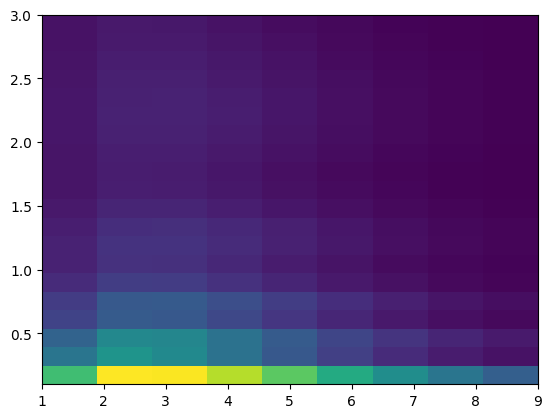

In [31]:
data = np.array(full_data)

plt.figure()
plt.imshow(
    abs(data),
    origin="lower",
    aspect="auto",
    extent=[ns[0], ns[-1], alphas[0], alphas[-1]]
)


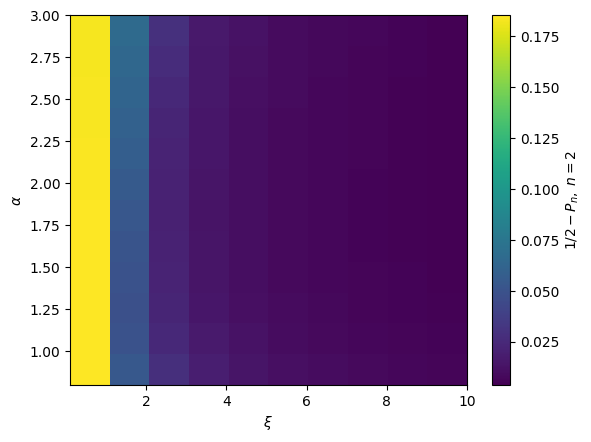

In [51]:
# full_data has shape:
# full_data[alpha_index][tau_index][n_index]

# choose which n you want
n_select = 2                 # e.g. ns[n_select]
n_idx = list(ns).index(n_select) # or directly set n_idx if you know it

# build 2D array: rows = alpha, columns = tau
import numpy as np

Z = np.array([
    [full_data[i][j][n_idx] for j in range(len(taus_alpha[i]))]
    for i in range(len(alphas))
])

# if taus_alpha is the same for all alpha, take one representative


plt.imshow(
    abs(Z),
    origin="lower",
    aspect="auto",
    extent=[xis[0], xis[-1], alphas[0], alphas[-1]]
)
plt.xlabel(r"$\xi$")
plt.ylabel(r"$\alpha$")
plt.colorbar(label=rf"$1/2 - P_n,\; n={n_select}$")
plt.show()


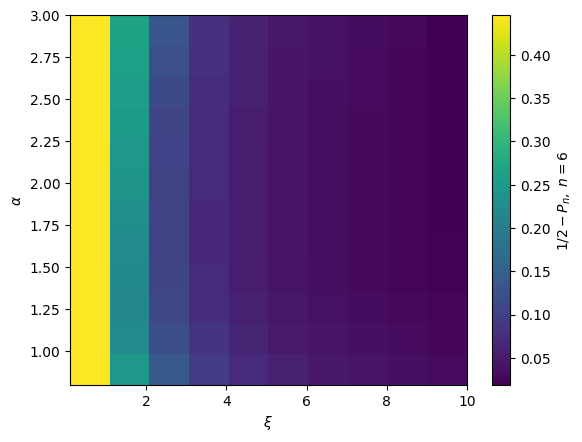

In [52]:
# full_data has shape:
# full_data[alpha_index][tau_index][n_index]

# choose which n you want
n_select = 6               # e.g. ns[n_select]
n_idx = list(ns).index(n_select) # or directly set n_idx if you know it

# build 2D array: rows = alpha, columns = tau
import numpy as np

Z = np.array([
    [full_data[i][j][n_idx] for j in range(len(taus_alpha[i]))]
    for i in range(len(alphas))
])

# if taus_alpha is the same for all alpha, take one representative


plt.imshow(
    abs(Z),
    origin="lower",
    aspect="auto",
    extent=[xis[0], xis[-1], alphas[0], alphas[-1]]
)
plt.xlabel(r"$\xi$")
plt.ylabel(r"$\alpha$")
plt.colorbar(label=rf"$1/2 - P_n,\; n={n_select}$")
plt.show()


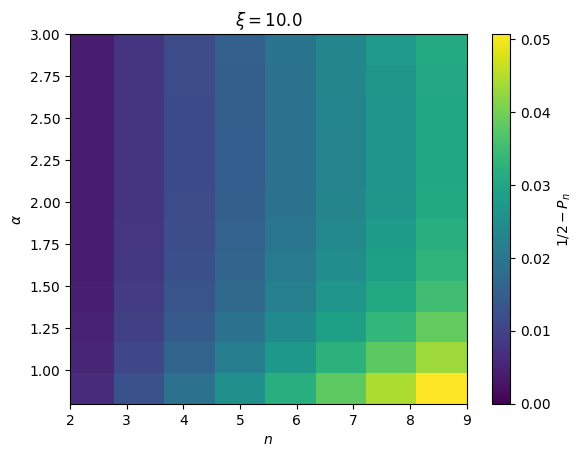

In [60]:
# select xi by index
xi_idx = -1          # choose which xi (index into xis / taus)
xi_val = xis[xi_idx]

# build 2D array: rows = alpha, columns = n
Z_xi = np.array([
    [full_data[i][xi_idx][k] for k in range(len(ns))]
    for i in range(len(alphas))
])

plt.imshow(
    abs(Z_xi),
    origin="lower",
    aspect="auto",
    extent=[ns[0], ns[-1], alphas[0], alphas[-1]]
)
xlim(ns[1],ns[-1])
plt.xlabel(r"$n$")
plt.ylabel(r"$\alpha$")
plt.title(rf"$\xi = {xi_val}$")
plt.colorbar(label=r"$1/2 - P_n$")
plt.show()
